# Pipeline Final — Detección de Grietas en Concreto
## Actividad 2 · Visión Artificial · UNIR · MIA
**Dataset:** SDNET2018  
**Preprocesado:** Filtro Bilateral (d=9)  
**Pipeline:** Bilateral → Sobel → Otsu → Apertura+Cierre (Disco 3×3) → Black Hat (15×15) → Otsu

---
### Justificación del pipeline
| Etapa | Técnica | Justificación |
|---|---|---|
| Preprocesado | Filtro Bilateral d=9 | Suaviza ruido preservando bordes de grieta — superior al Gaussiano en imágenes con textura |
| Detección de bordes | Sobel | Mayor robustez ante bajo contraste que el Laplaciano |
| Binarización | Umbral de Otsu | Cálculo automático del umbral óptimo sin intervención manual |
| Limpieza | Apertura + Cierre Disco 3×3 | Elimina ruido puntual y rellena huecos sin destruir la grieta (1–5 px) |
| Extracción fina | Black Hat 15×15 + Otsu | Extrae estructuras oscuras (grieta) sobre fondo claro directamente en gris |


---
## Sección 0 — Importaciones y carga de imágenes


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings
warnings.filterwarnings("ignore")

# ── Rutas ─────────────────────────────────────────────────────────────────
IMAGENES = {
    "Grieta sutil (001-130)":      "001-130.jpg",
    "Grieta visible (001-145)":    "001-145.jpg",
    "Grieta ramificada (010-123)": "010-123.jpg",
}

imgs_rgb  = {}
imgs_gray = {}

for nombre, ruta in IMAGENES.items():
    bgr = cv2.imread(ruta)
    if bgr is None:
        print(f"[!] No encontrado: {ruta}")
        continue
    imgs_rgb[nombre]  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    imgs_gray[nombre] = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

print(f"Imágenes cargadas: {len(imgs_gray)}")
for n, img in imgs_gray.items():
    print(f"  {n}: {img.shape}  media={img.mean():.1f}  std={img.std():.1f}")


Imágenes cargadas: 3
  Grieta sutil (001-130): (256, 256)  media=108.6  std=19.8
  Grieta visible (001-145): (256, 256)  media=104.6  std=14.6
  Grieta ramificada (010-123): (256, 256)  media=144.5  std=20.3


---
## Sección 1 — Preprocesado: Filtro Bilateral

El filtro bilateral pondera cada píxel vecino según **dos criterios simultáneos**:
1. Distancia espacial (como el Gaussiano)
2. Similitud de intensidad

$$B(x,y) = \frac{1}{W_p} \sum_{q \in S} G_{\sigma_s}(||p-q||) \cdot G_{\sigma_r}(|I_p - I_q|) \cdot I_q$$

Donde:
- $G_{\sigma_s}$: kernel gaussiano espacial (penaliza vecinos lejanos)
- $G_{\sigma_r}$: kernel gaussiano de rango (penaliza vecinos con intensidad diferente)
- $W_p$: factor de normalización

**Resultado:** suaviza zonas uniformes (fondo de concreto) pero respeta los
bordes abruptos (grieta) porque los píxeles al otro lado del borde tienen
intensidad muy diferente y reciben peso casi cero.

Parámetros usados: `d=9` (diámetro de vecindad), `sigmaColor=75`, `sigmaSpace=75`


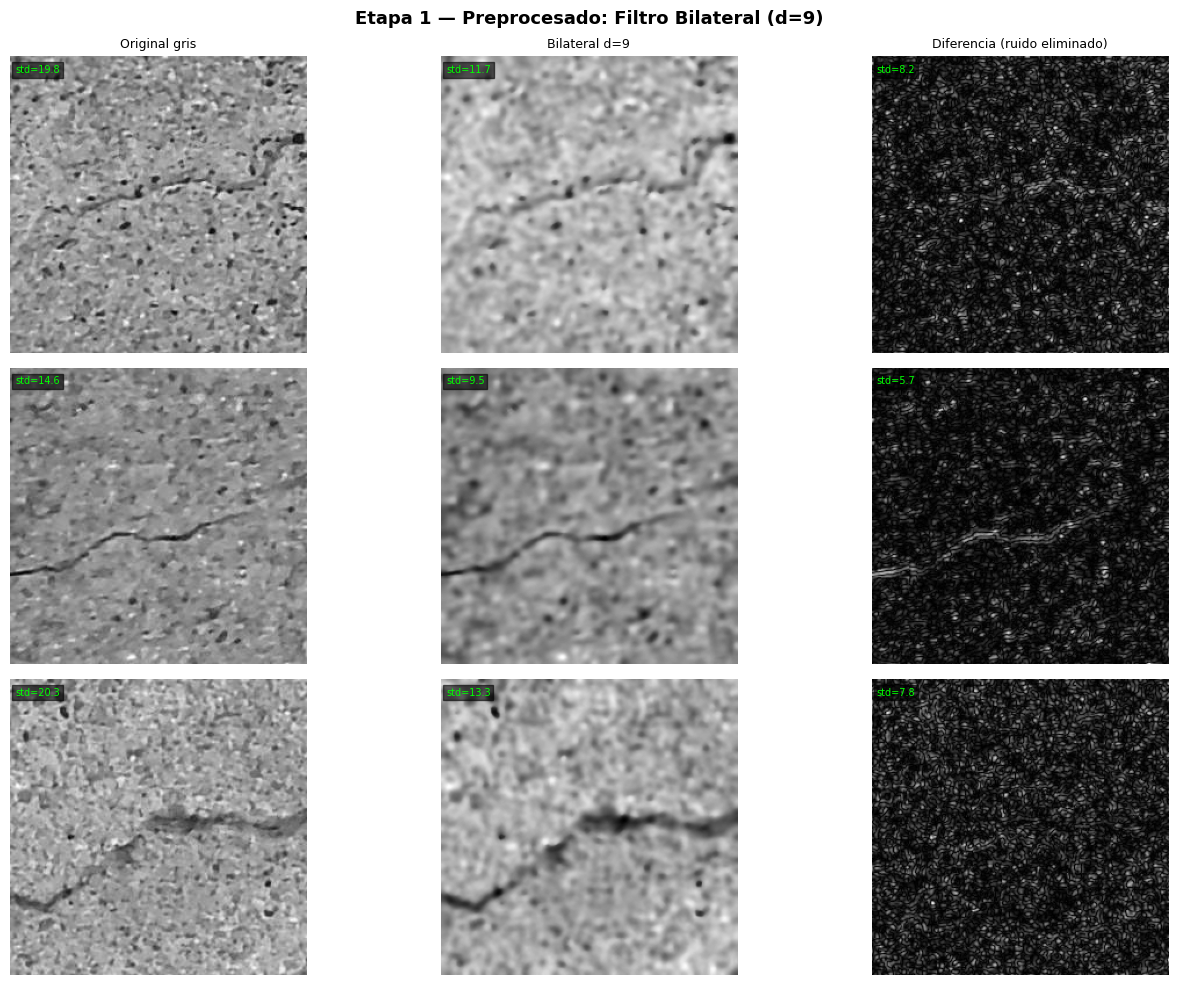

In [2]:
# ── Filtro Bilateral ──────────────────────────────────────────────────────
imgs_bilateral = {}

fig, axes = plt.subplots(len(imgs_gray), 3, figsize=(14, 10))
fig.suptitle("Etapa 1 — Preprocesado: Filtro Bilateral (d=9)",
             fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    bilateral = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    imgs_bilateral[nombre] = bilateral
    diff = cv2.absdiff(gray, bilateral)

    for col, (titulo, img) in enumerate(zip(
        ["Original gris", "Bilateral d=9", "Diferencia (ruido eliminado)"],
        [gray, bilateral, diff]
    )):
        axes[fila, col].imshow(img, cmap="gray")
        if fila == 0: axes[fila, col].set_title(titulo, fontsize=9)
        axes[fila, col].axis("off")
        axes[fila, col].text(4, 14, f"std={img.std():.1f}",
            color="lime", fontsize=7,
            bbox=dict(facecolor="black", alpha=0.6, pad=2))
    axes[fila, 0].set_ylabel(nombre, fontsize=8)

plt.tight_layout()
plt.savefig("fp_01_bilateral.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 2 — Detección de bordes: Sobel

$$G_x = \begin{bmatrix}-1&0&+1\\-2&0&+2\\-1&0&+1\end{bmatrix}*I
\qquad
G_y = \begin{bmatrix}-1&-2&-1\\0&0&0\\+1&+2&+1\end{bmatrix}*I
\qquad
|G| = \sqrt{G_x^2 + G_y^2}$$

Se aplica sobre la imagen bilateral — el preprocesado previo garantiza que
el gradiente responde a la grieta y no al ruido de textura.


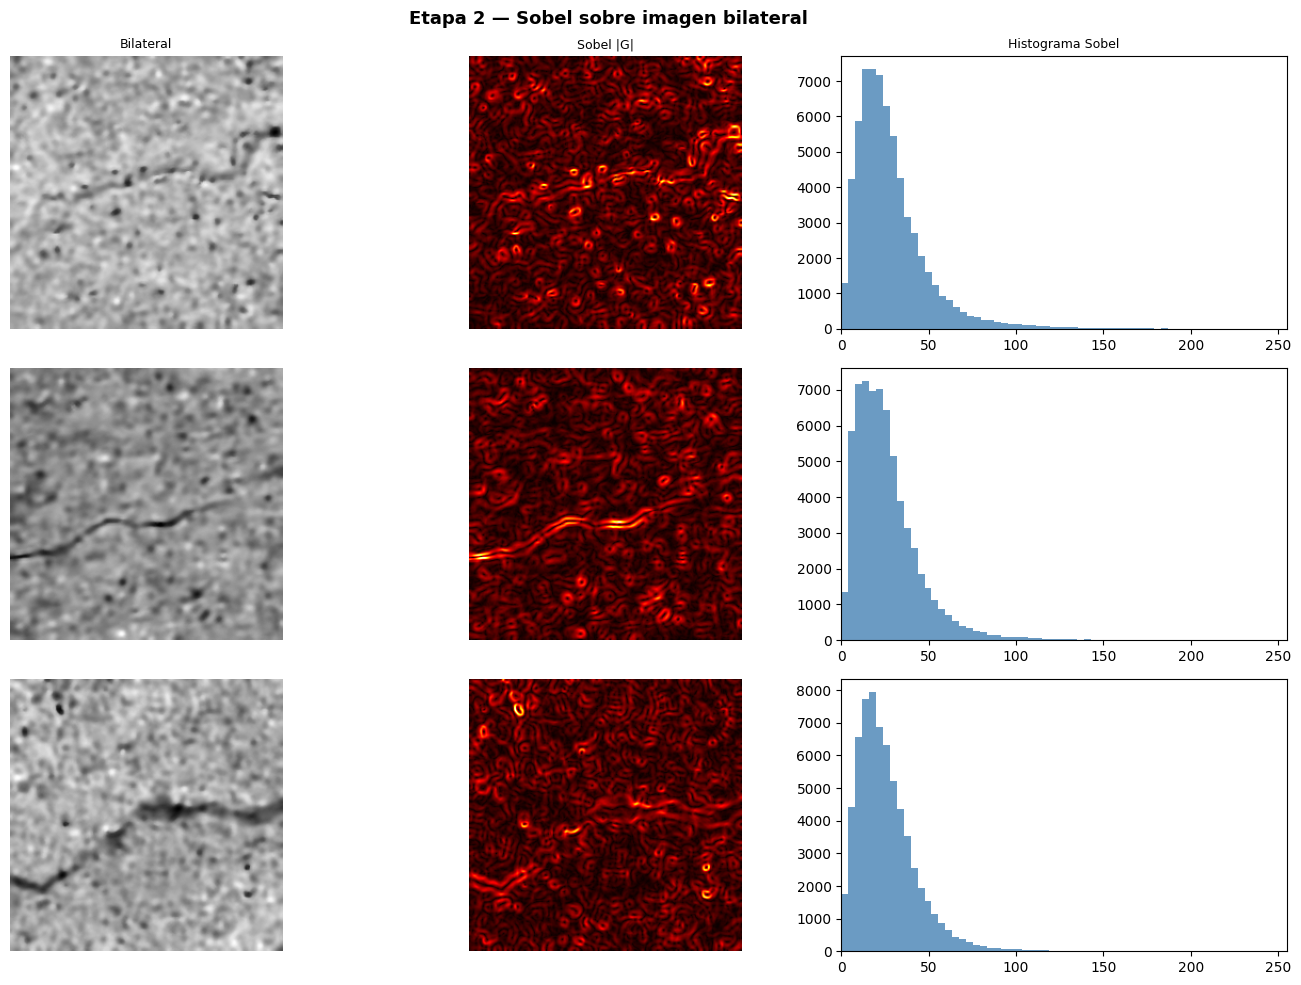

In [3]:
# ── Sobel sobre imagen bilateral ──────────────────────────────────────────
bordes_sobel = {}

fig, axes = plt.subplots(len(imgs_gray), 3, figsize=(14, 10))
fig.suptitle("Etapa 2 — Sobel sobre imagen bilateral",
             fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    blur = imgs_bilateral[nombre]
    Gx   = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    Gy   = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    mag  = np.sqrt(Gx**2 + Gy**2)
    sobel = np.uint8(255 * mag / mag.max())
    bordes_sobel[nombre] = sobel

    for col, (titulo, img, cm) in enumerate([
        ("Bilateral", blur, "gray"),
        ("Sobel |G|", sobel, "hot"),
        ("Histograma Sobel", None, None),
    ]):
        if col < 2:
            axes[fila, col].imshow(img, cmap=cm)
            axes[fila, col].axis("off")
        else:
            axes[fila, col].hist(sobel.ravel(), bins=64,
                                  color="steelblue", alpha=0.8)
            axes[fila, col].set_xlim(0, 255)
        if fila == 0: axes[fila, col].set_title(titulo, fontsize=9)
    axes[fila, 0].set_ylabel(nombre, fontsize=8)

plt.tight_layout()
plt.savefig("fp_02_sobel.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 3 — Binarización: Umbral de Otsu

$$B(x,y) = \begin{cases}255 & \text{si } I(x,y) > \tau_{Otsu} \\ 0 & \text{si no}\end{cases}$$

Otsu maximiza la varianza entre clases (fondo vs. borde) calculando τ
automáticamente desde el histograma.


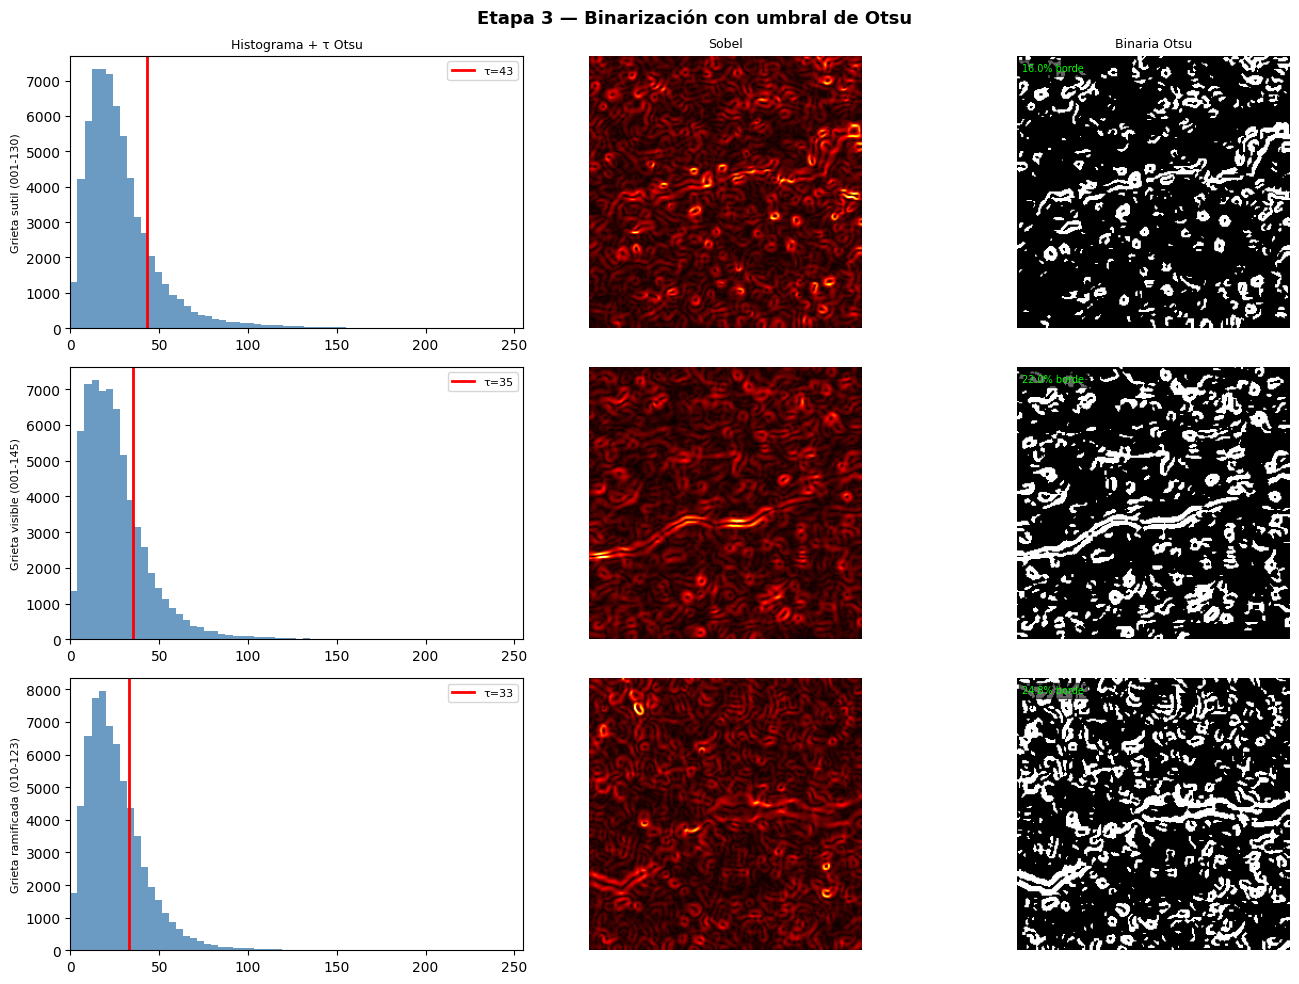

In [4]:
# ── Binarización Otsu sobre Sobel ─────────────────────────────────────────
binarias = {}

fig, axes = plt.subplots(len(imgs_gray), 3, figsize=(14, 10))
fig.suptitle("Etapa 3 — Binarización con umbral de Otsu",
             fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    sobel = bordes_sobel[nombre]
    tau   = threshold_otsu(sobel)
    bin_  = (sobel > tau).astype(np.uint8) * 255
    binarias[nombre] = bin_
    pct = bin_.mean() / 255 * 100

    axes[fila, 0].hist(sobel.ravel(), bins=64, color="steelblue", alpha=0.8)
    axes[fila, 0].axvline(tau, color="red", lw=2, label=f"τ={tau:.0f}")
    axes[fila, 0].legend(fontsize=8)
    axes[fila, 0].set_xlim(0, 255)
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    if fila == 0: axes[fila, 0].set_title("Histograma + τ Otsu", fontsize=9)

    axes[fila, 1].imshow(sobel, cmap="hot")
    if fila == 0: axes[fila, 1].set_title("Sobel", fontsize=9)
    axes[fila, 1].axis("off")

    axes[fila, 2].imshow(bin_, cmap="gray")
    if fila == 0: axes[fila, 2].set_title("Binaria Otsu", fontsize=9)
    axes[fila, 2].axis("off")
    axes[fila, 2].text(4, 14, f"{pct:.1f}% borde", color="lime", fontsize=7,
        bbox=dict(facecolor="black", alpha=0.6, pad=2))

plt.tight_layout()
plt.savefig("fp_03_otsu.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 4 — Morfología: Apertura → Cierre (Disco 3×3)

| Operación | Definición | Efecto |
|---|---|---|
| **Apertura** $I \ominus SE \oplus SE$ | Erosión → Dilatación | Elimina ruido puntual |
| **Cierre** $I \oplus SE \ominus SE$ | Dilatación → Erosión | Rellena huecos |

SE seleccionado: **Disco 3×3** — mínimo viable para grietas de 1–5 px de ancho.
SEs mayores destruyen la grieta durante la erosión previa a la apertura.


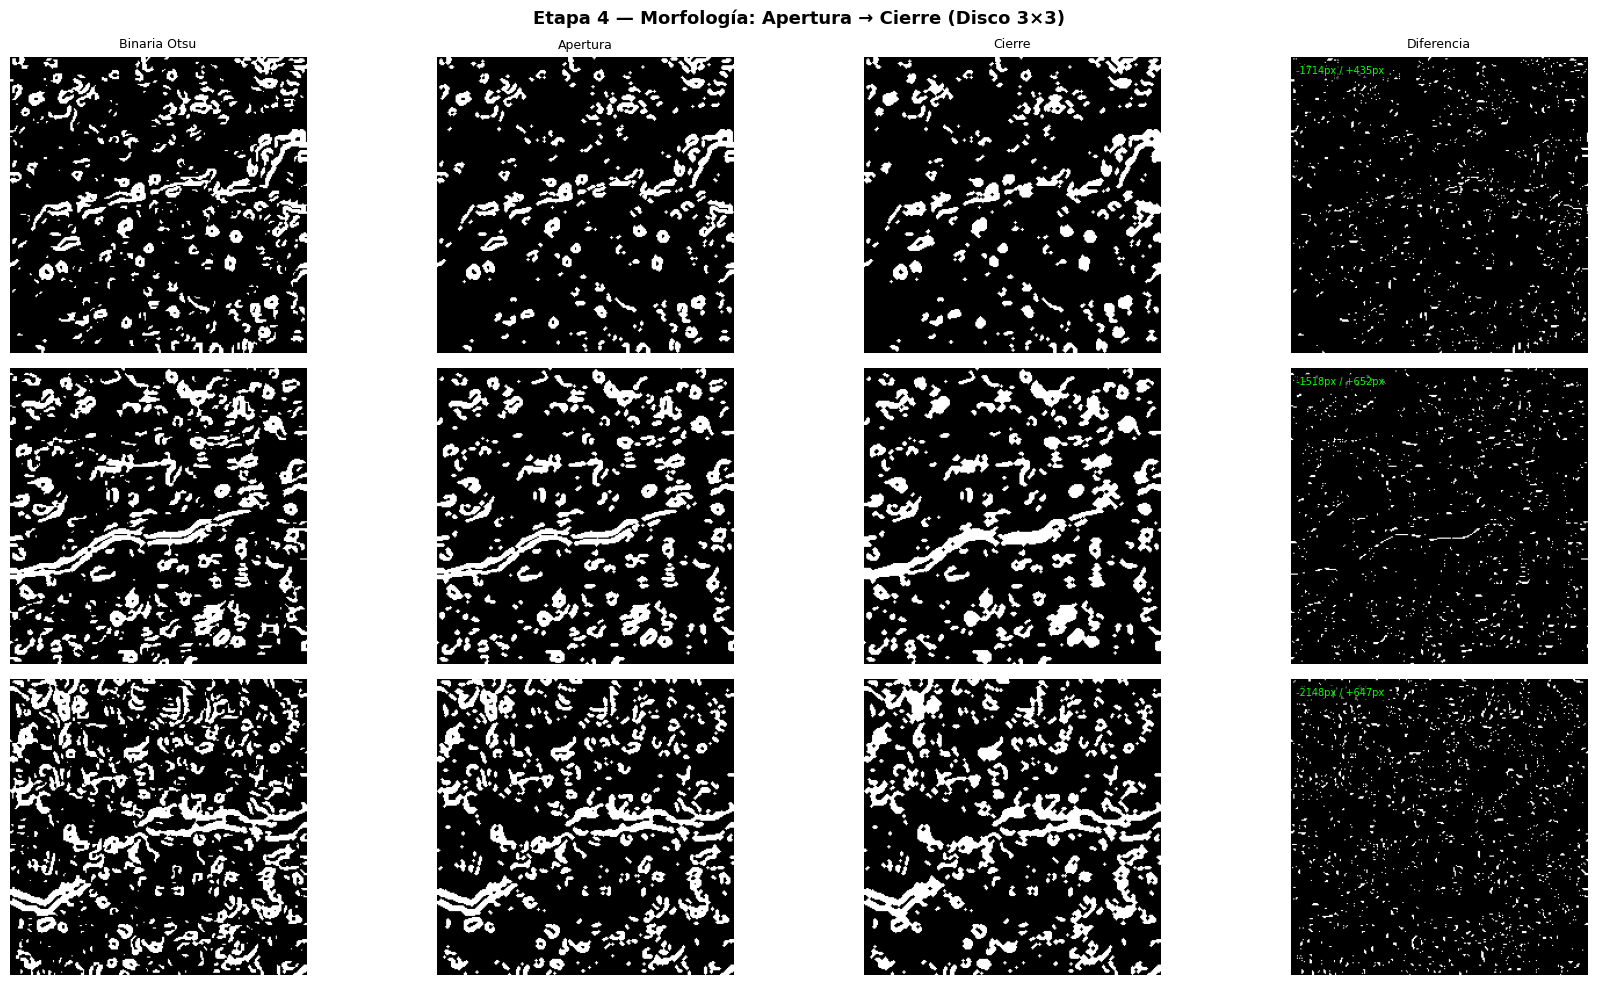

In [5]:
# ── Apertura → Cierre (Disco 3×3) ────────────────────────────────────────
SE_MORF = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
morfologicas = {}

fig, axes = plt.subplots(len(imgs_gray), 4, figsize=(18, 10))
fig.suptitle("Etapa 4 — Morfología: Apertura → Cierre (Disco 3×3)",
             fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    bin_     = binarias[nombre]
    apertura = cv2.morphologyEx(bin_,     cv2.MORPH_OPEN,  SE_MORF)
    cierre   = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, SE_MORF)
    morfologicas[nombre] = cierre
    diff = cv2.absdiff(bin_, cierre)

    elim = ((bin_==255)&(cierre==0)).sum()
    agre = ((bin_==0)&(cierre==255)).sum()

    for col, (titulo, img) in enumerate(zip(
        ["Binaria Otsu", "Apertura", "Cierre", "Diferencia"],
        [bin_, apertura, cierre, diff]
    )):
        axes[fila, col].imshow(img, cmap="gray")
        if fila == 0: axes[fila, col].set_title(titulo, fontsize=9)
        axes[fila, col].axis("off")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    axes[fila, 3].text(4, 14, f"-{elim}px / +{agre}px",
        color="lime", fontsize=7,
        bbox=dict(facecolor="black", alpha=0.6, pad=2))

plt.tight_layout()
plt.savefig("fp_04_morfologia.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 5 — Black Hat + Otsu (operación avanzada)

$$\text{Black Hat}(I) = \text{Cierre}(I) - I$$

Extrae estructuras **oscuras** más pequeñas que el SE — exactamente las grietas.
Operando sobre la imagen bilateral en gris elimina la necesidad de binarizar
primero, produciendo una segmentación más limpia.

SE: **Rect 15×15** — mayor que la grieta (1–5 px) pero selectivo ante
variaciones de iluminación del fondo.


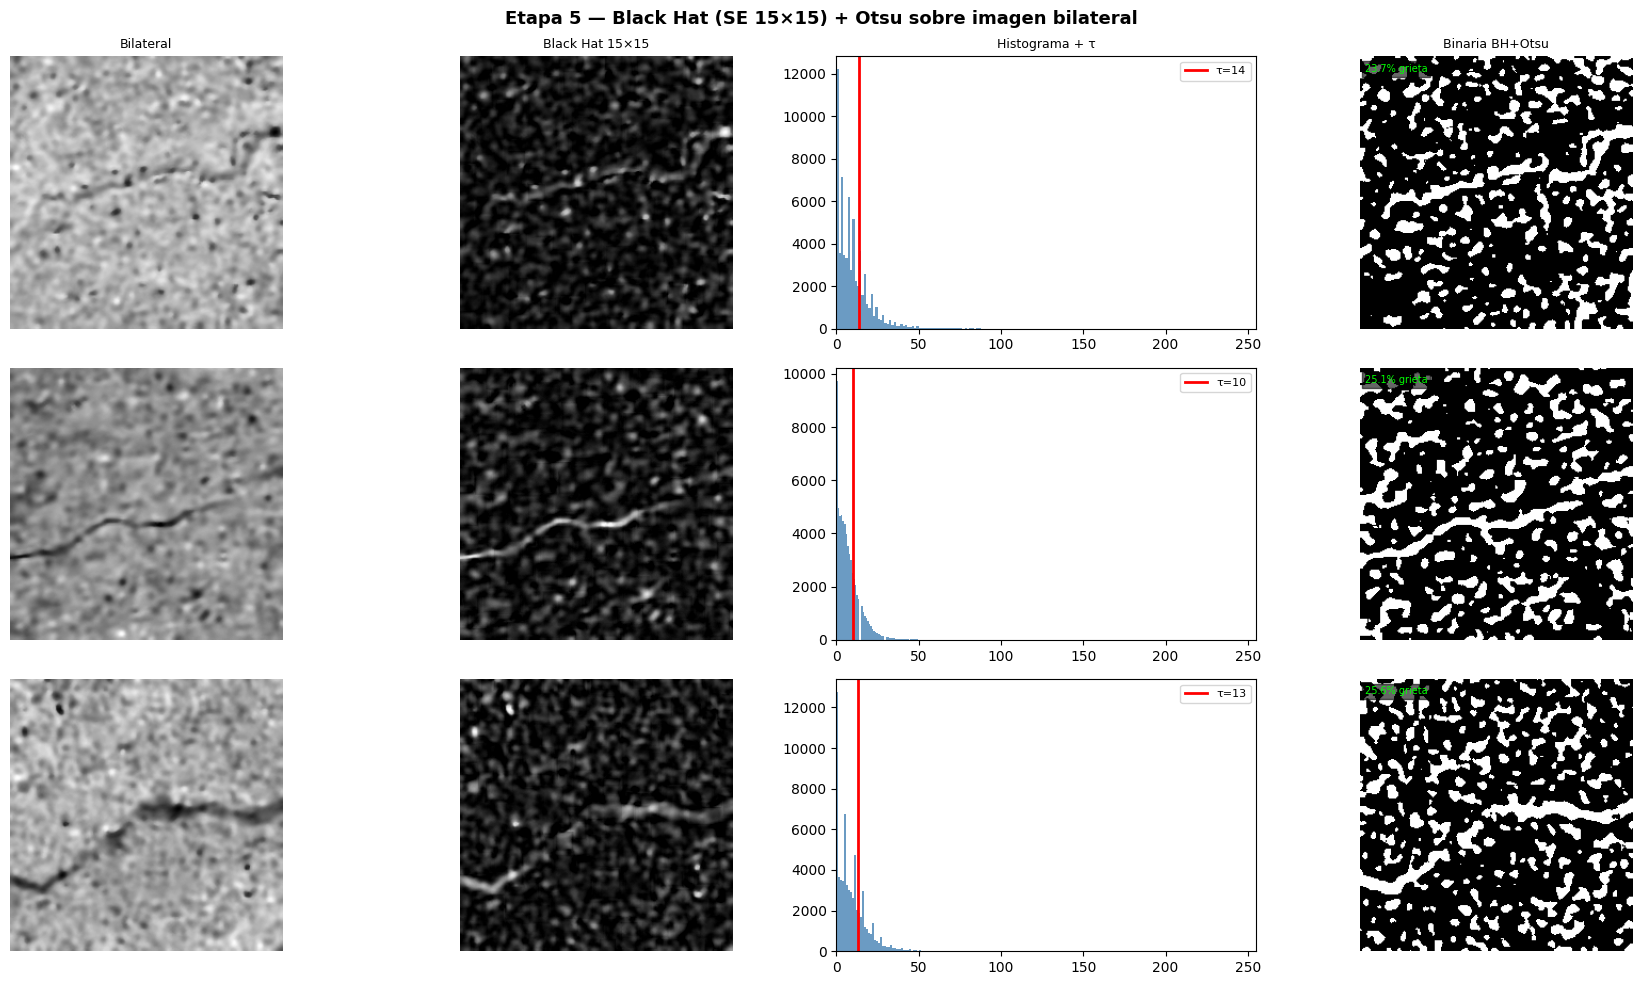

In [6]:
# ── Black Hat 15×15 + Otsu ───────────────────────────────────────────────
SE_BH = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
blackhat_final = {}
binarias_bh    = {}

fig, axes = plt.subplots(len(imgs_gray), 4, figsize=(18, 10))
fig.suptitle("Etapa 5 — Black Hat (SE 15×15) + Otsu sobre imagen bilateral",
             fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    blur  = imgs_bilateral[nombre]
    bh    = cv2.morphologyEx(blur, cv2.MORPH_BLACKHAT, SE_BH)
    tau   = threshold_otsu(bh)
    bin_bh = (bh > tau).astype(np.uint8) * 255
    blackhat_final[nombre] = bh
    binarias_bh[nombre]    = bin_bh
    pct = bin_bh.mean() / 255 * 100

    for col, (titulo, img) in enumerate(zip(
        ["Bilateral", "Black Hat 15×15", "Histograma + τ", "Binaria BH+Otsu"],
        [blur, bh, None, bin_bh]
    )):
        if col == 2:
            axes[fila, col].hist(bh.ravel(), bins=64,
                                  color="steelblue", alpha=0.8)
            axes[fila, col].axvline(tau, color="red", lw=2,
                                     label=f"τ={tau:.0f}")
            axes[fila, col].legend(fontsize=8)
            axes[fila, col].set_xlim(0, 255)
        else:
            axes[fila, col].imshow(img, cmap="gray")
            axes[fila, col].axis("off")
        if fila == 0: axes[fila, col].set_title(titulo, fontsize=9)
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    axes[fila, 3].text(4, 14, f"{pct:.1f}% grieta", color="lime", fontsize=7,
        bbox=dict(facecolor="black", alpha=0.6, pad=2))

plt.tight_layout()
plt.savefig("fp_05_blackhat.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Sección 6 — Panel resumen y métricas comparativas

### Métricas utilizadas
| Métrica | Qué mide |
|---|---|
| **std** | Contraste global — mayor = más variación de intensidad |
| **PSNR** | Fidelidad respecto al original — menor = mayor transformación |
| **% área** | Fracción de píxeles detectados como grieta |


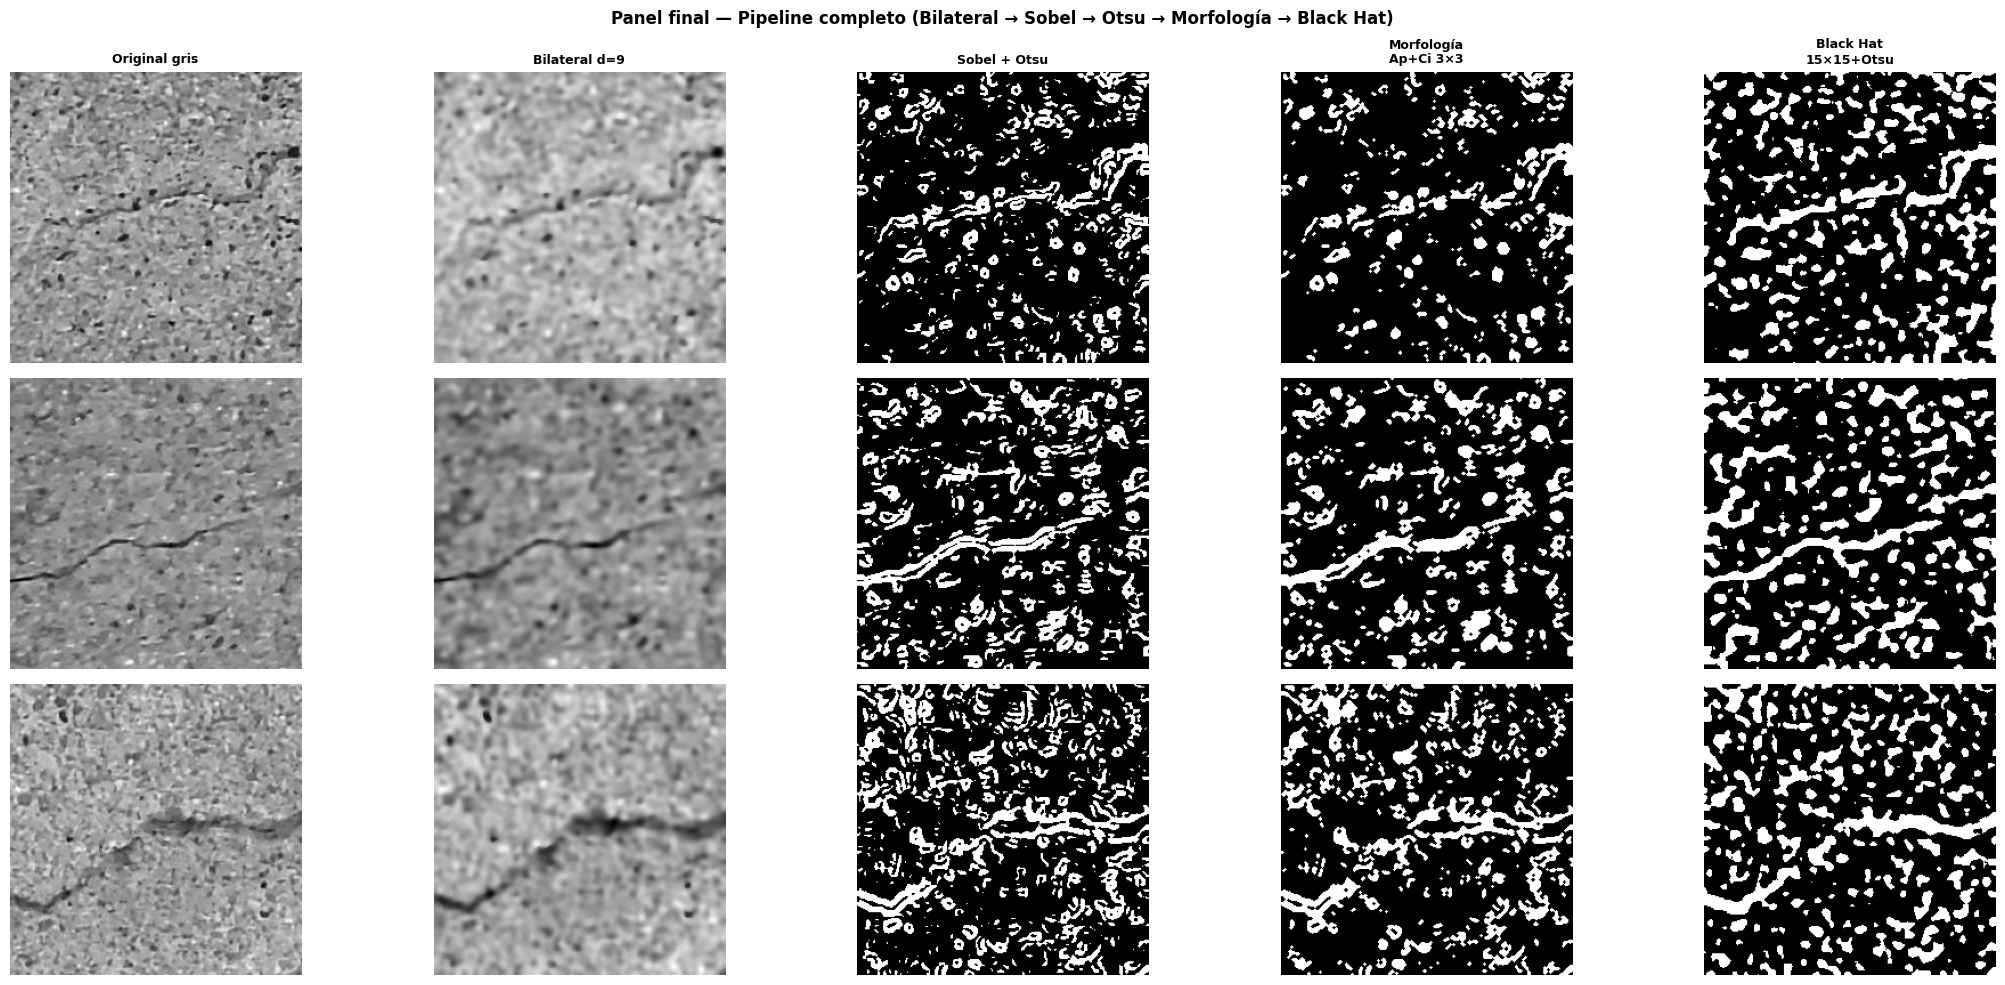

In [7]:
# ── Panel final: pipeline completo de un vistazo ─────────────────────────
etapas = [
    ("Original gris",          lambda n: imgs_gray[n]),
    ("Bilateral d=9",          lambda n: imgs_bilateral[n]),
    ("Sobel + Otsu",           lambda n: binarias[n]),
    ("Morfología\nAp+Ci 3×3", lambda n: morfologicas[n]),
    ("Black Hat\n15×15+Otsu", lambda n: binarias_bh[n]),
]

fig, axes = plt.subplots(len(imgs_gray), len(etapas), figsize=(22, 10))
fig.suptitle("Panel final — Pipeline completo (Bilateral → Sobel → Otsu → Morfología → Black Hat)",
             fontsize=12, fontweight="bold")

for col, (titulo, fn) in enumerate(etapas):
    axes[0, col].set_title(titulo, fontsize=9, fontweight="bold")

for fila, nombre in enumerate(imgs_gray):
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    for col, (titulo, fn) in enumerate(etapas):
        axes[fila, col].imshow(fn(nombre), cmap="gray")
        axes[fila, col].axis("off")

plt.tight_layout()
plt.savefig("fp_06_panel_final.png", dpi=200, bbox_inches="tight")
plt.show()


In [8]:
# ── Tabla de métricas ─────────────────────────────────────────────────────
print(f"{'Imagen':<30} {'std orig':>10} {'std bilat':>10} {'std BH':>10} "
      f"{'PSNR bilat':>12} {'% morf':>10} {'% BH+Otsu':>10}")
print("-" * 95)

for nombre in imgs_gray:
    gray   = imgs_gray[nombre]
    bilat  = imgs_bilateral[nombre]
    bh     = blackhat_final[nombre]
    morf   = morfologicas[nombre]
    bin_bh = binarias_bh[nombre]

    psnr_b = psnr(gray, bilat, data_range=255)

    print(f"{nombre:<30} {gray.std():>10.2f} {bilat.std():>10.2f} "
          f"{bh.std():>10.2f} {psnr_b:>12.2f} "
          f"{morf.mean()/255*100:>10.2f}% {bin_bh.mean()/255*100:>10.2f}%")

print()
print("Figuras generadas:")
for f in ["fp_01_bilateral.png","fp_02_sobel.png","fp_03_otsu.png",
          "fp_04_morfologia.png","fp_05_blackhat.png","fp_06_panel_final.png"]:
    print(f"  {f}")


Imagen                           std orig  std bilat     std BH   PSNR bilat     % morf  % BH+Otsu
-----------------------------------------------------------------------------------------------
Grieta sutil (001-130)              19.77      11.73       9.65        26.50      14.03%      23.68%
Grieta visible (001-145)            14.58       9.55       7.24        30.04      20.73%      25.09%
Grieta ramificada (010-123)         20.30      13.29       9.24        26.64      22.55%      25.60%

Figuras generadas:
  fp_01_bilateral.png
  fp_02_sobel.png
  fp_03_otsu.png
  fp_04_morfologia.png
  fp_05_blackhat.png
  fp_06_panel_final.png
